In [1]:
%pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/world_bank_clean.csv")
sns.set_theme(style="whitegrid")
print("Data loaded and plotting libraries initialized!")

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.9 MB 2.3 MB/s eta 0:00:01██████████████▋            | 4.8 MB 2.3 MB/s eta 0:00:02
     |████████████████████████████████| 294 kB 20.1 MB/s eta 0:00:01
     |████████████████████████████████| 2.4 MB 8.8 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 6.7 MB/s  eta 0:00:01
     |████████████████████████████████| 5.3 MB 23.0 MB/s eta 0:00:01
     |████████████████████████████████| 265 kB 10.5 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 27.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Data loaded and plotting libraries initialized!


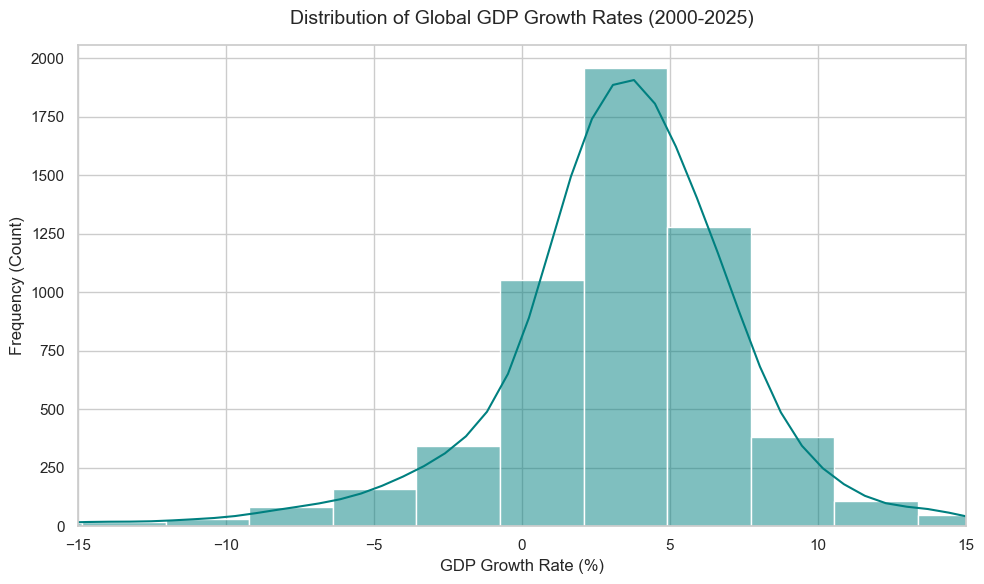

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="gdp_growth", kde=True, bins=50, color="teal")
plt.title("Distribution of Global GDP Growth Rates (2000-2025)", fontsize=14, pad=15)
plt.xlabel("GDP Growth Rate (%)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.xlim(-15, 15)  # Zooms in on the main distribution body
plt.tight_layout()
plt.show()

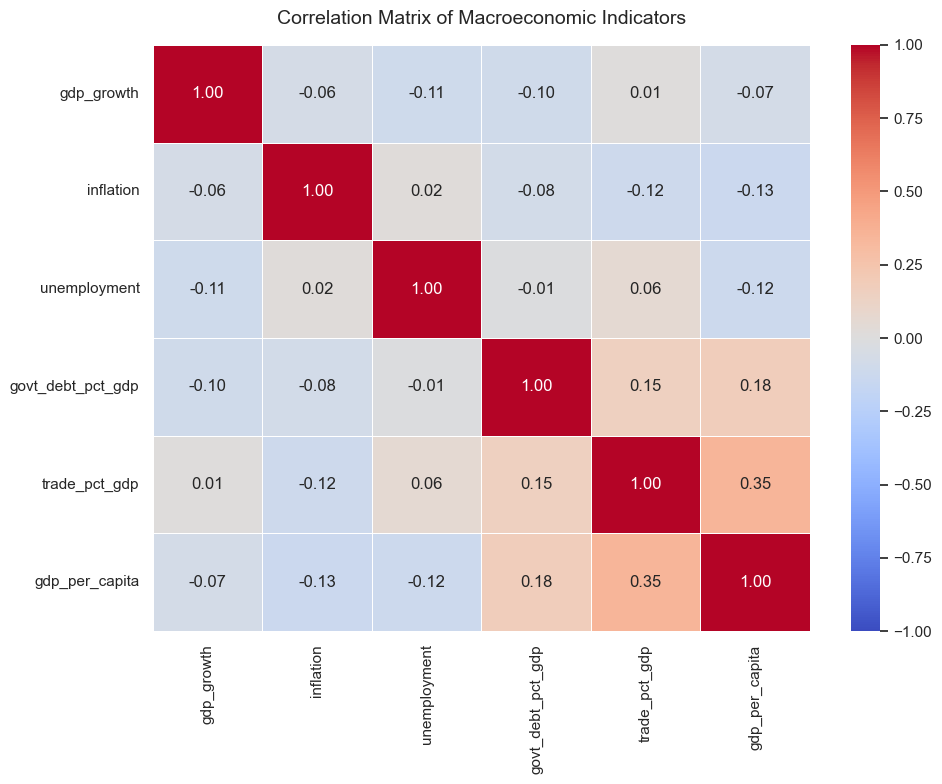

In [3]:
plt.figure(figsize=(10, 8))
numeric_cols = ["gdp_growth", "inflation", "unemployment", "govt_debt_pct_gdp", "trade_pct_gdp", "gdp_per_capita"]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Macroeconomic Indicators", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

/var/folders/d7/6xbrn4v15d149hyfn6m1gtym0000gn/T/ipykernel_27684/1959884745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="income_group", y="gdp_growth", order=income_order, palette="Set2")


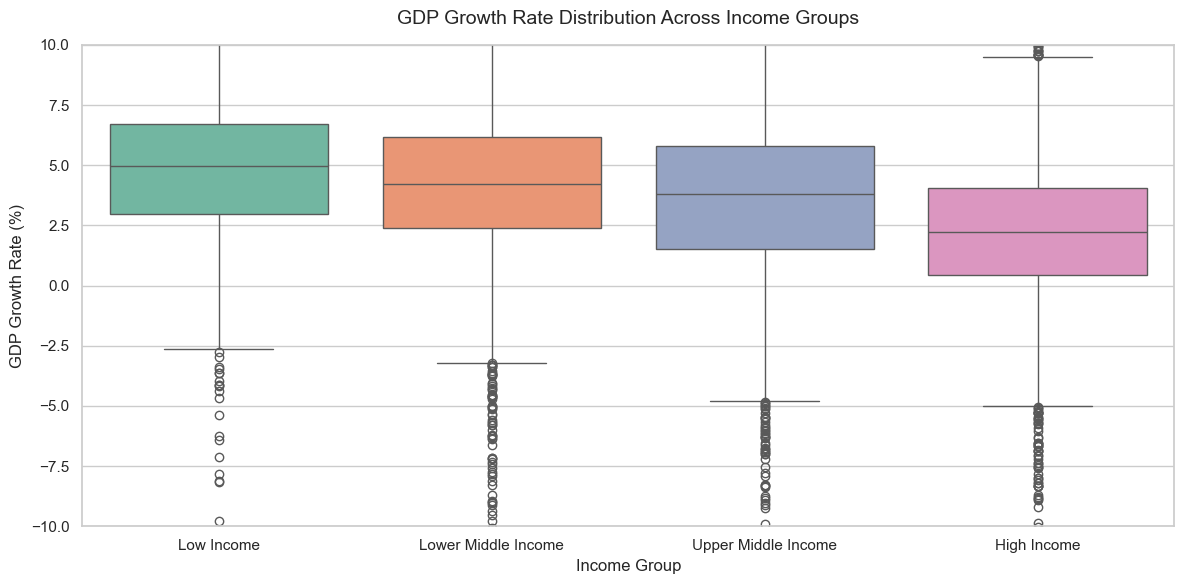

In [4]:
plt.figure(figsize=(12, 6))
income_order = ["Low Income", "Lower Middle Income", "Upper Middle Income", "High Income"]

sns.boxplot(data=df, x="income_group", y="gdp_growth", order=income_order, palette="Set2")
plt.title("GDP Growth Rate Distribution Across Income Groups", fontsize=14, pad=15)
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("GDP Growth Rate (%)", fontsize=12)
plt.ylim(-10, 10)  # Caps the axis slightly to clearly focus on the main boxes
plt.tight_layout()
plt.show()

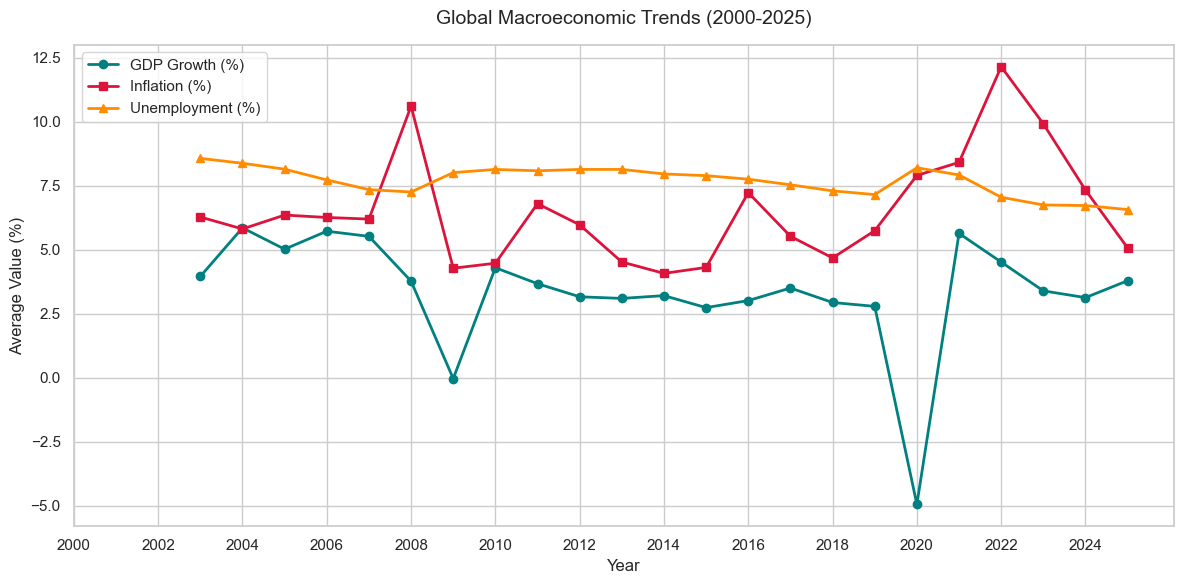

In [5]:
plt.figure(figsize=(12, 6))
yearly_avg = df.groupby("year")[["gdp_growth", "inflation", "unemployment"]].mean().reset_index()

plt.plot(yearly_avg["year"], yearly_avg["gdp_growth"], marker="o", label="GDP Growth (%)", color="teal", linewidth=2)
plt.plot(yearly_avg["year"], yearly_avg["inflation"], marker="s", label="Inflation (%)", color="crimson", linewidth=2)
plt.plot(yearly_avg["year"], yearly_avg["unemployment"], marker="^", label="Unemployment (%)", color="darkorange", linewidth=2)

plt.title("Global Macroeconomic Trends (2000-2025)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Value (%)", fontsize=12)
plt.xticks(range(2000, 2026, 2))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()